# CDD API - Conversational Diagram Designer

This notebook demonstrates the CDD system end-to-end. It is the canonical
API tutorial that follows GP's `template.API.ipynb` pattern.

**Pipeline:** natural language → LLM → diagram code → renderer → image
→ (optional) multimodal vision critique → corrected code → re-render → loop
(cap: 3 iterations).

**Supports:** Graphviz DOT, Mermaid, PlantUML.

**How to run:**
1. `./docker_build.sh`
2. `./docker_jupyter.sh`
3. Open this notebook and run all cells

Or launch the React UI: `./docker_app.sh` → http://localhost:8000

## 1. Setup

In [1]:
import os
import sys

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import cdd_config as config
import cdd_llm as llm
import cdd_renderer as renderer
from cdd_orchestrator import CDDOrchestrator
from IPython.display import Image, SVG, display

print(f"Default LLM provider: {config.LLM_PROVIDER}")
print(f"Supported formats: {config.SUPPORTED_FORMATS}")
print(f"Vision feedback enabled by default: {config.VISION_FEEDBACK_ENABLED}")
print(f"Vision iteration cap: {config.VISION_MAX_ITERATIONS}")

Default LLM provider: gemini
Supported formats: ['graphviz', 'mermaid', 'plantuml']
Vision feedback enabled by default: True
Vision iteration cap: 3


## 2. Single-shot generation: Graphviz

Generate a Graphviz DOT diagram from a natural language description.
This is the simplest CDD interaction.

In [2]:
orch = CDDOrchestrator(format="graphviz")
prompt_1 = (
    "Flowchart: Start -> Login -> if valid go to Dashboard, if invalid show Error"
)
diagram_source, image_bytes = orch.process_message(prompt_1)
print("Generated DOT source:")
print(diagram_source)

Generated DOT source:
digraph Flowchart {
    graph [label="Login Flowchart", labelloc="t", fontname="Helvetica"];
    node [fontname="Helvetica", fontsize=10];
    edge [fontname="Helvetica", fontsize=9];

    start [shape=oval, label="Start", style=filled, fillcolor="#DDEEFF"];
    login [shape=box, label="Login", style=filled, fillcolor="#CCEEFF"];
    validate [shape=diamond, label="Credentials\nValid?", style=filled, fillcolor="#FFFFCC"];
    dashboard [shape=box, label="Dashboard", style=filled, fillcolor="#CCFFCC"];
    error [shape=box, label="Show Error", style=filled, fillcolor="#FFCCCC"];

    start -> login;
    login -> validate;
    validate:e -> dashboard [label="Yes", color="green"];
    validate:w -> error [label="No", color="red"];
}


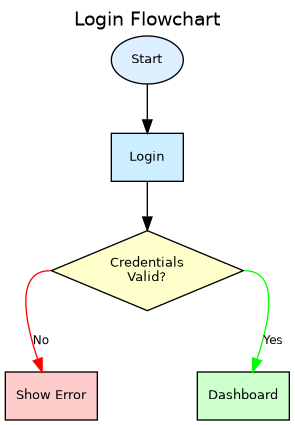

Iterations used: 5


In [3]:
display(Image(data=image_bytes))
print(f"Iterations used: {len(orch.state.last_trace)}")

## 3. Multi-turn refinement

CDD keeps conversation history and modifies the existing diagram in place.

Revision: 2


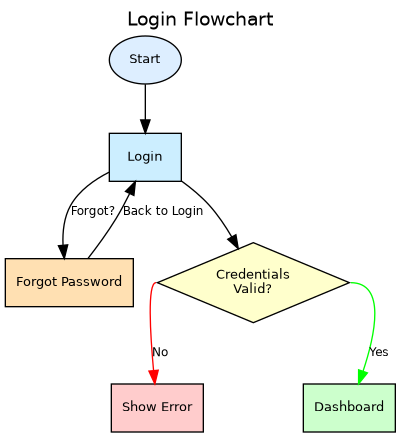

In [4]:
_, img2 = orch.process_message(
    "Add a Forgot Password node that links back to Login"
)
print(f"Revision: {orch.state.revision_count}")
display(Image(data=img2))

In [ ]:
#_, img3 = orch.process_message(
#    "Add two-factor authentication after credential validation, before dashboard"
#)
#print(f"Revision: {orch.state.revision_count}")
#display(Image(data=img3))

## 4. Mermaid format

Switching format means a new orchestrator (or reset). Here we generate a
Mermaid sequence diagram. Mermaid renders via the public Kroki server, so
this requires network access from the container.

Generated Mermaid source:
sequenceDiagram
    participant User
    participant Server

    User->>Server: Sends login credentials
    Server-->>User: Returns token
    User->>User: Stores token


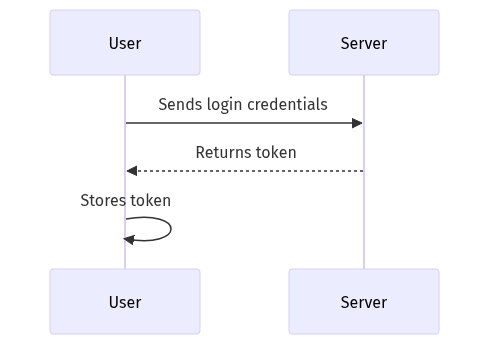

In [5]:
orch_m = CDDOrchestrator(format="mermaid")
mermaid_prompt = (
    "Sequence diagram: User sends login to Server. Server returns token. User stores token."
)
src_m, img_m = orch_m.process_message(mermaid_prompt)
print("Generated Mermaid source:")
print(src_m)
display(Image(data=img_m))

## 5. PlantUML format

PlantUML is rendered via the public PlantUML server (also network-dependent).

Generated PlantUML source:
@startuml
skinparam classAttributeIconSize 0

class Animal {
    - name: String
    - age: int
}

class Dog {
    - breed: String
}

class Cat {
    - indoor: boolean
}

class Kennel {
}

Animal <|-- Dog
Animal <|-- Cat

Kennel "1" -- "0..*" Dog : has
@enduml


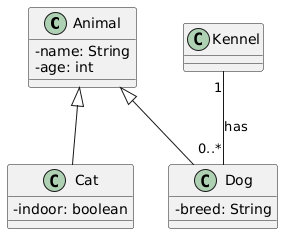

In [6]:
orch_p = CDDOrchestrator(format="plantuml")
plantuml_prompt = (
    "Class diagram: Animal (name, age), Dog extends Animal (breed), "
    "Cat extends Animal (indoor). Kennel has many Dogs."
)
src_p, img_p = orch_p.process_message(plantuml_prompt)
print("Generated PlantUML source:")
print(src_p)
display(Image(data=img_p))

## 6. Vision feedback loop in action

This is the centerpiece feature. With vision feedback enabled (the default),
CDD renders the diagram, sends the image to a multimodal model, gets a
critique, and iterates if the critique flags issues. Capped at 3 iterations.

The trace recorded in `orch.state.last_trace` shows every step.

In [8]:
orch_v = CDDOrchestrator(format="graphviz", vision_feedback=True, max_iterations=1)
_, _ = orch_v.process_message(
    "Three boxes: API Gateway -> Orders, API Gateway -> Payments"
)
print("Trace from this turn (each entry is one pipeline step):")
for step in orch_v.state.last_trace:
    print(f"  {step}")

Trace from this turn (each entry is one pipeline step):
  {'iteration': 1, 'step': 'generate', 'format': 'graphviz', 'code_length': 315}
  {'iteration': 1, 'step': 'rendered', 'image_bytes': 14764}
  {'iteration': 1, 'step': 'stop_max_iterations'}
  {'step': 'describe_suggest', 'has_description': True, 'suggestion_count': 3}


## 7. Vision feedback OFF (single-shot baseline)

For comparison: the same prompt with vision feedback disabled. This is
the baseline we use in the evaluation study (`cdd.example.ipynb`).

In [9]:
orch_baseline = CDDOrchestrator(format="graphviz", vision_feedback=False)
_, _ = orch_baseline.process_message(
    "Three boxes: API Gateway -> Orders, API Gateway -> Payments"
)
print("Trace (vision off — should show only one iteration):")
for step in orch_baseline.state.last_trace:
    print(f"  {step}")

Trace (vision off — should show only one iteration):
  {'iteration': 1, 'step': 'generate', 'format': 'graphviz', 'code_length': 191}
  {'iteration': 1, 'step': 'rendered', 'image_bytes': 11440}
  {'iteration': 1, 'step': 'stop_vision_disabled'}
  {'step': 'describe_suggest', 'has_description': True, 'suggestion_count': 3}


## 8. Different diagram types

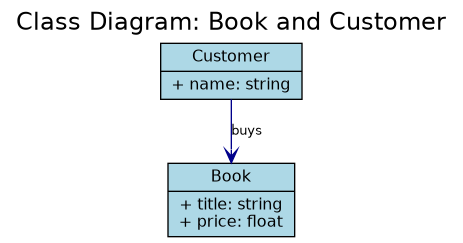

In [10]:
orch_class = CDDOrchestrator(format="graphviz")
_, img_c = orch_class.process_message(
    "Class diagram: Book (title, price). Customer (name). Customer buys Book."
)
display(Image(data=img_c))

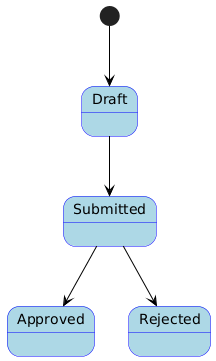

In [11]:
orch_sm = CDDOrchestrator(format="plantuml")
_, img_s = orch_sm.process_message(
    "State machine: Draft -> Submitted -> Approved or Rejected"
)
display(Image(data=img_s))

## 9. Export

In [12]:
orch.export_dot("/tmp/login_flow.dot")
orch.export_image("/tmp/login_flow.png", fmt="png")
orch.export_image("/tmp/login_flow.svg", fmt="svg")
print("Exported DOT, PNG, SVG to /tmp/")

Exported DOT, PNG, SVG to /tmp/


## 10. Validation

The renderer validates source before rendering, so syntax errors are
caught early and surface a clear error.

Bad DOT — Valid: True, Error: 
Good DOT — Valid: True


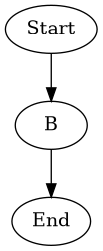

In [13]:
bad_dot = "digraph { this is invalid }"
is_valid, error = renderer.validate(bad_dot, "graphviz")
print(f"Bad DOT — Valid: {is_valid}, Error: {error[:80]}")

good_dot = 'digraph { A -> B -> C; A [label="Start"]; C [label="End"]; }'
is_valid, _ = renderer.validate(good_dot, "graphviz")
print(f"Good DOT — Valid: {is_valid}")
display(Image(data=renderer.render(good_dot, "graphviz")))

## 11. State inspection

In [14]:
import json

state = orch.get_state_dict()
print(f"Format: {state['format']}")
print(f"Revisions: {state['revision_count']}")
print(f"Conversation turns: {len(state['conversation_history']) // 2}")
print(f"Last trace step count: {len(state['last_trace'])}")

Format: graphviz
Revisions: 2
Conversation turns: 2
Last trace step count: 5
